In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

In [6]:
#loading the data
df = pd.read_csv("project_train.csv")

#cleaning the data
df = df.drop_duplicates()
df = df.dropna()

#converting categorical data to numeric
df_labels = df["satisfaction"].map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

df_features = df[[
    "Gender", "Customer Type", "Age", "Type of Travel", "Class",
    "Flight Distance", "Inflight wifi service",
    "Departure/Arrival time convenient", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding", "Seat comfort",
    "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service",
    "Cleanliness", "Departure Delay in Minutes", "Arrival Delay in Minutes"
]]

#convert categorical to dummy variables
df_features = pd.get_dummies(df_features, drop_first=True)

#split data into training and testing
x_train, x_test, y_train, y_test = train_test_split(df_features, df_labels, test_size=0.2, random_state=42)

In [4]:
#Week 8 tutorial
logistic = LogisticRegression(solver="lbfgs", max_iter=10000)
mlp = MLPClassifier(solver="lbfgs", alpha=1e-5,
                    hidden_layer_sizes=(8,2), random_state=11, max_iter=10000)

#train models
logistic.fit(x_train, y_train)
mlp.fit(x_train, y_train)

#testing models
logistic_test = logistic.predict(x_test)
mlp_test = mlp.predict(x_test)

#accuracy scores
logistic_accuracy = accuracy_score(y_test, logistic_test)
mlp_accuracy = accuracy_score(y_test, mlp_test)
print(f"Logistic Regression Accuracy: {logistic_accuracy}")
print(f"MLP Accuracy: {mlp_accuracy}")

Logistic Regression Accuracy: 0.8731116366620011
MLP Accuracy: 0.5625271489936773


In [7]:
#classification reports
print("Logistic Regression Classification Report:")
print(classification_report(y_test, logistic_test, target_names=["dissatisfied","satisfied"], zero_division=0))
print(" ")
print("MLP Classification Report:")
print(classification_report(y_test, mlp_test, target_names=["dissatisfied","satisfied"], zero_division=0))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

dissatisfied       0.87      0.91      0.89     11655
   satisfied       0.87      0.83      0.85      9064

    accuracy                           0.87     20719
   macro avg       0.87      0.87      0.87     20719
weighted avg       0.87      0.87      0.87     20719

 
MLP Classification Report:
              precision    recall  f1-score   support

dissatisfied       0.56      1.00      0.72     11655
   satisfied       0.00      0.00      0.00      9064

    accuracy                           0.56     20719
   macro avg       0.28      0.50      0.36     20719
weighted avg       0.32      0.56      0.41     20719



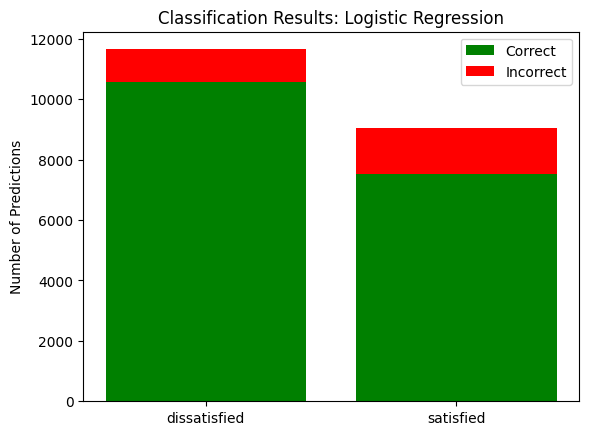

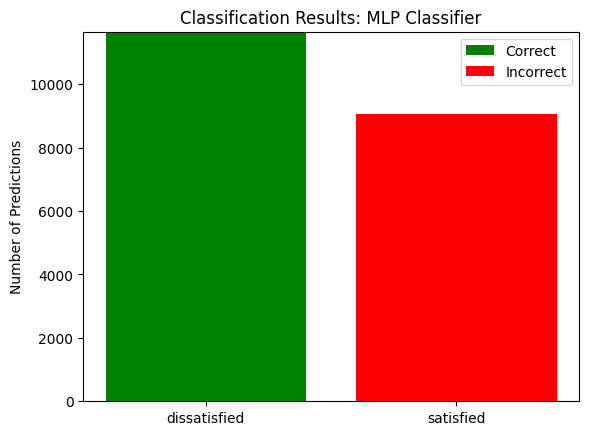

In [8]:
def classification_visualization(true_data, test_model, model_name="Model"):
    model_confusion = confusion_matrix(true_data, test_model)
    model_labels = ["dissatisfied", "satisfied"]

    model_correct = np.diag(model_confusion)
    incorrect = model_confusion.sum(axis=1) - model_correct

    plt.bar(model_labels, model_correct, label="Correct", color="green")
    plt.bar(model_labels, incorrect, bottom=model_correct, label="Incorrect", color="red")
    plt.ylabel("Number of Predictions")
    plt.title(f"Classification Results: {model_name}")
    plt.legend()
    plt.show()

classification_visualization(y_test, logistic_test, model_name="Logistic Regression")
classification_visualization(y_test, mlp_test, model_name="MLP Classifier")

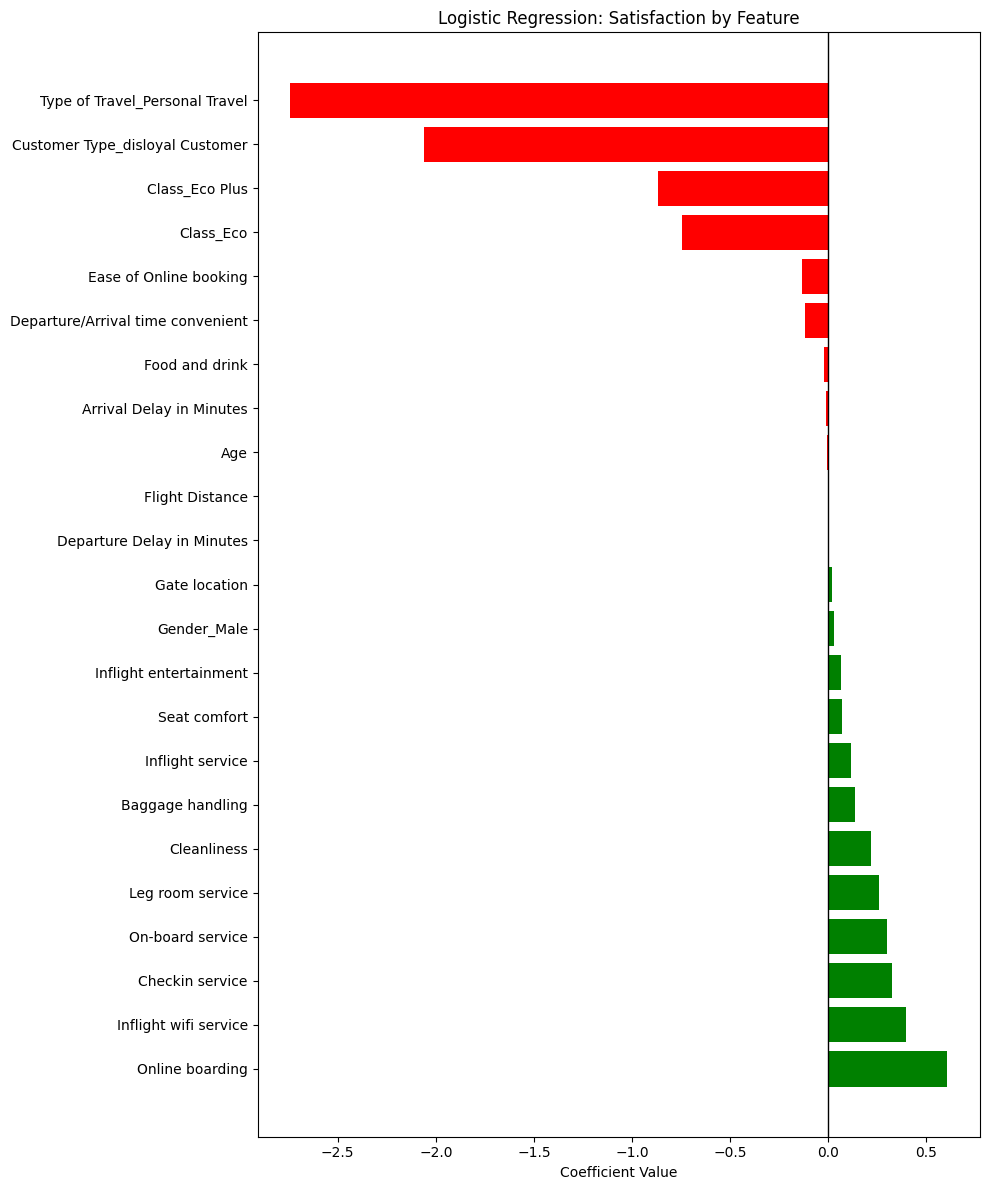

In [10]:
df_coefficient = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": logistic.coef_[0]
}).sort_values("Coefficient", ascending=False)

#coefficient plot
plt.figure(figsize=(10,12))
colors = ['green' if val > 0 else 'red' for val in df_coefficient["Coefficient"]]
plt.barh(df_coefficient["Feature"], df_coefficient["Coefficient"], color=colors)
plt.title("Logistic Regression: Satisfaction by Feature")
plt.xlabel("Coefficient Value")
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [11]:
#impact scores
df_impact = df_coefficient.copy()
df_impact["absolute_coefficient"] = df_impact["Coefficient"].abs()

df_impact["stdev"] = x_train.std().values
df_impact["impact_score"] = df_impact["absolute_coefficient"] * df_impact["stdev"]

df_impact = df_impact.sort_values("impact_score", ascending=False)

print("\nTop 10 high-impact features airlines should target:")
print(df_impact.head(10))


Top 10 high-impact features airlines should target:
                              Feature  Coefficient  absolute_coefficient  \
2               Inflight wifi service     0.398128              0.398128   
7                     Online boarding     0.605769              0.605769   
3   Departure/Arrival time convenient    -0.119616              0.119616   
19    Customer Type_disloyal Customer    -2.059261              2.059261   
6                      Food and drink    -0.020026              0.020026   
20     Type of Travel_Personal Travel    -2.741126              2.741126   
10                   On-board service     0.300939              0.300939   
13                    Checkin service     0.326787              0.326787   
22                     Class_Eco Plus    -0.870318              0.870318   
11                   Leg room service     0.256152              0.256152   

         stdev  impact_score  
2   997.171077    397.001449  
7    15.106402      9.150997  
3    38.690653   

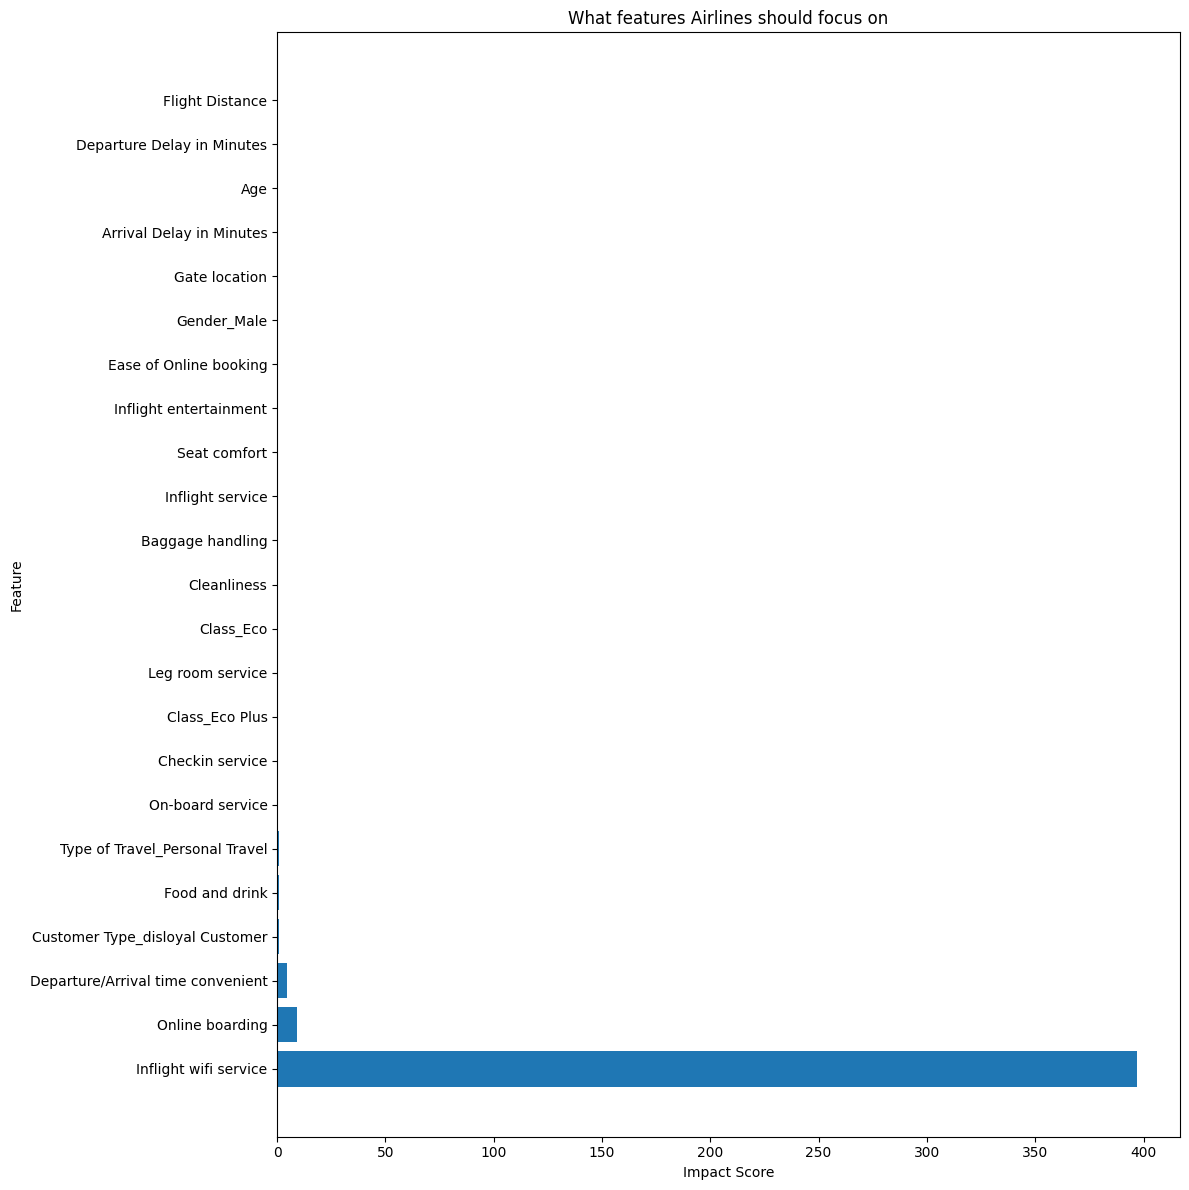

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
plt.barh(df_impact["Feature"], df_impact["impact_score"])
plt.xlabel("Impact Score")
plt.ylabel("Feature")
plt.title("What features Airlines should focus on")
plt.tight_layout()
plt.show()
